# Random Forest Robustness Analysis
### Chronological (out-of-time) validation, Leave-One-Month-Out CV, grid-search tuning, SHAP tracking, and bootstrap confidence intervals

**Purpose.** Companion to `05_LogisticRegression_Robustness.ipynb`, applying the same out-of-time protocol to **Random Forest**. It re-evaluates the model previously fit in `SHAP.ipynb` / `analysis.ipynb` under:

1. **Out-of-time (chronological) holdout** — train on Feb-Sep, test on Oct-Nov-Dec.
2. **Leave-One-Month-Out (LOMO) cross-validation** — each month held out in turn, tracking both performance and `Month_Nov`'s SHAP-importance rank per fold, using the same TreeExplainer configuration (`tree_path_dependent`, `check_additivity=False`) already used in `SHAP.ipynb` for comparability.

Hyperparameters are selected by an inner 5-fold grid search on the chronological training partition only, over the same parameter family already reported as tuned in the manuscript (n_estimators, min_samples_leaf, max_features, max_depth).

**This notebook does not modify or overwrite `SHAP.ipynb` / `analysis.ipynb`.** All outputs use an `rf_` prefix so they cannot be confused with the original random-split results.

> As with the Logistic Regression notebook: `Month_Oct`/`Month_Nov`/`Month_Dec` are constant in the chronological training partition, so that split reports **aggregate predictive performance only**. `Month_Nov`'s SHAP-rank stability is assessed via LOMO, where it is only excluded from training in the one fold where it is the held-out target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import joblib

try:
    import shap
except ImportError as e:
    raise ImportError(
        "This notebook requires the 'shap' package (already a dependency of "
        "SHAP.ipynb / XAI.ipynb in the original project)."
    ) from e

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, precision_score, recall_score,
    brier_score_loss, confusion_matrix
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

MONTH_ORDER = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
SHAP_EVAL_SAMPLE_SIZE = 500  # matches SHAP.ipynb's fixed evaluation sample size


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (y_prob >= lo) & (y_prob <= hi) if i == n_bins - 1 else (y_prob >= lo) & (y_prob < hi)
        n = mask.sum()
        if n == 0:
            continue
        ece += (n / N) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece


def positive_class_shap(raw_shap_values):
    """Normalize shap_values() output across shap versions/binary-classifier shapes
    to a single (n_samples, n_features) array for the positive class."""
    if isinstance(raw_shap_values, list):
        return raw_shap_values[1]
    arr = np.asarray(raw_shap_values)
    if arr.ndim == 3:
        return arr[:, :, 1]
    return arr


def evaluate_clf(model, X_te_s, y_te, label):
    y_pred = model.predict(X_te_s)
    y_prob = model.predict_proba(X_te_s)[:, 1]
    return {
        "Split": label,
        "N_test": int(len(y_te)),
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "ROC_AUC": round(roc_auc_score(y_te, y_prob), 4),
        "PR_AUC": round(average_precision_score(y_te, y_prob), 4),
        "F1": round(f1_score(y_te, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall": round(recall_score(y_te, y_pred), 4),
        "Brier": round(brier_score_loss(y_te, y_prob), 4),
        "ECE": round(expected_calibration_error(y_te.to_numpy(), y_prob), 4),
    }


In [3]:
df = pd.read_csv("online_shoppers_intention.csv")
assert set(df["Month"].unique()) == set(MONTH_ORDER), \
    "MONTH_ORDER does not match the months present in the data - check for a schema change."
NOMINAL_INT_COLS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[NOMINAL_INT_COLS] = df[NOMINAL_INT_COLS].astype("category")

df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
y = df_encoded["Revenue"]
X = df_encoded.drop("Revenue", axis=1)
X = X.drop(columns=["PageValues", "BounceRates", "ExitRates"])

month_rank_map = {m: i for i, m in enumerate(MONTH_ORDER)}

print("X shape:", X.shape)


X shape: (12330, 65)


## 1. Out-of-time (chronological) split

In [4]:
TEST_MONTHS = ["Oct", "Nov", "Dec"]

train_mask = ~df["Month"].isin(TEST_MONTHS)
test_mask = df["Month"].isin(TEST_MONTHS)

X_train_chrono, X_test_chrono = X[train_mask], X[test_mask]
y_train_chrono, y_test_chrono = y[train_mask], y[test_mask]

train_months_present = sorted(df.loc[train_mask, "Month"].unique(), key=lambda m: month_rank_map[m])
print(f"Chronological split - train: {X_train_chrono.shape[0]} sessions, months: {train_months_present}")
print(f"Chronological split - test:  {X_test_chrono.shape[0]} sessions, months: {TEST_MONTHS}")


Chronological split - train: 7056 sessions, months: ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep']
Chronological split - test:  5274 sessions, months: ['Oct', 'Nov', 'Dec']


### 1.1 Hyperparameter tuning (inner 5-fold grid search, chronological training partition only)

Search space mirrors the parameter family already reported as tuned for Random Forest in the manuscript (n_estimators, min_samples_leaf, max_features, max_depth).

In [5]:
scaler_chrono = StandardScaler()
X_train_chrono_s = scaler_chrono.fit_transform(X_train_chrono)
X_test_chrono_s = scaler_chrono.transform(X_test_chrono)

param_grid = {
    "n_estimators": [100, 300, 500],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 10, 20],
}
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    scoring="average_precision",
    cv=inner_cv,
    n_jobs=-1,
)
grid_search.fit(X_train_chrono_s, y_train_chrono)

best_params = grid_search.best_params_
print("Selected Random Forest hyperparameters (inner 5-fold, scoring = PR-AUC):", best_params)

cv_grid_df = pd.DataFrame(grid_search.cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")
cv_grid_df.to_csv("rf_gridsearch_chronological.csv", index=False)
cv_grid_df.head(10)


Selected Random Forest hyperparameters (inner 5-fold, scoring = PR-AUC): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}


,params,mean_test_score,std_test_score,rank_test_score
8,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.300051,0.032074,1
7,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.300030,0.030711,2
4,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.299499,0.030508,3
5,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.299249,0.032236,4
6,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.299052,0.028492,5
43,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.297370,0.028651,6
42,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.296908,0.027337,7
44,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.296541,0.029455,8
41,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.295999,0.032756,9
14,"{'max_depth': None, 'max_features': 'log2', 'm...",0.293971,0.029961,10


### 1.2 Evaluate the tuned model on the chronological holdout

In [6]:
rf_chrono = grid_search.best_estimator_

chrono_result = evaluate_clf(rf_chrono, X_test_chrono_s, y_test_chrono,
                              f"Chronological (train={train_months_present}, test={TEST_MONTHS})")
chrono_result.update({f"Selected_{k}": v for k, v in best_params.items()})
chrono_result_df = pd.DataFrame([chrono_result])
chrono_result_df.to_csv("rf_chronological_holdout_results.csv", index=False)
chrono_result_df


,Split,N_test,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier,ECE,Selected_max_depth,Selected_max_features,Selected_min_samples_leaf,Selected_n_estimators
0,"Chronological (train=['Feb', 'Mar', 'May', 'Ju...",5274,0.6809,0.6481,0.2903,0.32,0.1167,0.2861,0.363,0.1959,0.1789,None,sqrt,5,500


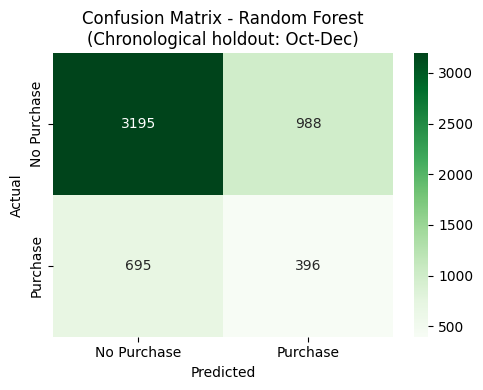

In [7]:
y_pred_chrono = rf_chrono.predict(X_test_chrono_s)
cm_chrono = confusion_matrix(y_test_chrono, y_pred_chrono)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_chrono, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest\n(Chronological holdout: Oct-Dec)")
plt.tight_layout()
plt.savefig("rf_confusion_matrix_chronological.png", dpi=200, bbox_inches="tight")
plt.show()


In [8]:
# 1.4 Matched-feature chronological comparison (LR vs RF, full vs leakage-free)
leak = ["PageValues", "BounceRates", "ExitRates"]
X_full = df_encoded.drop(columns="Revenue")        # 68 predictors
X_lf   = X_full.drop(columns=leak)                 # 65 predictors
test = test_mask.to_numpy()

rows = []
for name, Xa in [("full", X_full), ("leakage-free", X_lf)]:
    sc = StandardScaler().fit(Xa[~test])
    Xtr, Xte = sc.transform(Xa[~test]), sc.transform(Xa[test])
    ytr, yte = y[~test], y[test]

    lr = LogisticRegression(C=1, class_weight="balanced", max_iter=20000,
                            random_state=RANDOM_STATE).fit(Xtr, ytr)
    rf = RandomForestClassifier(**best_params, class_weight="balanced",
                                random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
    for m, mod in [("Logistic Regression", lr), ("Random Forest", rf)]:
        p = mod.predict_proba(Xte)[:, 1]
        rows.append({"Feature set": name, "Model": m,
                     "ROC_AUC": round(roc_auc_score(yte, p), 4),
                     "PR_AUC": round(average_precision_score(yte, p), 4)})

matched_df = pd.DataFrame(rows)
matched_df.to_csv("matched_features_chronological.csv", index=False)
matched_df

,Feature set,Model,ROC_AUC,PR_AUC
0,full,Logistic Regression,0.8323,0.6172
1,full,Random Forest,0.8422,0.6611
2,leakage-free,Logistic Regression,0.6619,0.3231
3,leakage-free,Random Forest,0.6481,0.2903


### 1.3 SHAP feature importance on the chronological holdout

Same TreeExplainer configuration (`tree_path_dependent`, `check_additivity=False`) and fixed evaluation-sample size used throughout `SHAP.ipynb`, for direct comparability with the manuscript's reported rankings.

In [9]:
X_test_chrono_s_df = pd.DataFrame(X_test_chrono_s, columns=X.columns)
eval_sample_chrono = X_test_chrono_s_df.sample(
    n=min(SHAP_EVAL_SAMPLE_SIZE, len(X_test_chrono_s_df)), random_state=RANDOM_STATE
)

explainer_chrono = shap.TreeExplainer(rf_chrono, feature_perturbation="tree_path_dependent")
shap_values_chrono = positive_class_shap(
    explainer_chrono.shap_values(eval_sample_chrono, check_additivity=False)
)

shap_importance_chrono = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.abs(shap_values_chrono).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_importance_chrono["rank"] = shap_importance_chrono.index + 1
shap_importance_chrono.to_csv("rf_chronological_shap_importance.csv", index=False)

shap_importance_chrono.head(15)


,feature,mean_abs_shap,rank
0,ProductRelated_Duration,0.063299,1
1,ProductRelated,0.040731,2
2,VisitorType_Returning_Visitor,0.037773,3
3,Administrative_Duration,0.032129,4
4,TrafficType_2,0.028985,5
5,Administrative,0.028794,6
6,TrafficType_3,0.015942,7
7,OperatingSystems_3,0.014850,8
8,Informational_Duration,0.014589,9
9,OperatingSystems_2,0.012062,10


## 2. Leave-One-Month-Out (LOMO) cross-validation

Each month is held out in turn; the model is refit on the remaining months (using the tuned hyperparameters selected above), and evaluated on the held-out month. SHAP importance and `Month_Nov`'s rank are tracked per fold.

In [10]:
months_present = df["Month"].unique().tolist()

lomo_results = []
lomo_shap_records = []

for held_out_month in MONTH_ORDER:
    if held_out_month not in months_present:
        continue

    train_mask_m = df["Month"] != held_out_month
    test_mask_m = df["Month"] == held_out_month

    X_train_m, X_test_m = X[train_mask_m], X[test_mask_m]
    y_train_m, y_test_m = y[train_mask_m], y[test_mask_m]

    scaler_m = StandardScaler()
    X_train_m_s = scaler_m.fit_transform(X_train_m)
    X_test_m_s = scaler_m.transform(X_test_m)

    rf_m = RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        max_depth=best_params["max_depth"],
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_m.fit(X_train_m_s, y_train_m)

    row = evaluate_clf(rf_m, X_test_m_s, y_test_m, f"LOMO holdout: {held_out_month}")
    row["Held_out_month"] = held_out_month
    lomo_results.append(row)

    # SHAP on the held-out month itself (capped at SHAP_EVAL_SAMPLE_SIZE for tractability)
    X_test_m_s_df = pd.DataFrame(X_test_m_s, columns=X.columns)
    eval_sample_m = X_test_m_s_df.sample(
        n=min(SHAP_EVAL_SAMPLE_SIZE, len(X_test_m_s_df)), random_state=RANDOM_STATE
    )
    explainer_m = shap.TreeExplainer(rf_m, feature_perturbation="tree_path_dependent")
    shap_values_m = positive_class_shap(explainer_m.shap_values(eval_sample_m, check_additivity=False))

    shap_imp_m = pd.DataFrame({
        "feature": X.columns,
        "mean_abs_shap": np.abs(shap_values_m).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    shap_imp_m["rank"] = shap_imp_m.index + 1
    shap_imp_m["Held_out_month"] = held_out_month
    lomo_shap_records.append(shap_imp_m)

    print(f"Completed LOMO fold: held out {held_out_month} (n_test={len(y_test_m)})")

lomo_results_df = pd.DataFrame(lomo_results)
lomo_results_df = lomo_results_df[["Held_out_month"] + [c for c in lomo_results_df.columns if c != "Held_out_month"]]
lomo_results_df.to_csv("rf_lomo_results.csv", index=False)
lomo_results_df


Completed LOMO fold: held out Feb (n_test=184)
Completed LOMO fold: held out Mar (n_test=1907)
Completed LOMO fold: held out May (n_test=3364)
Completed LOMO fold: held out June (n_test=288)
Completed LOMO fold: held out Jul (n_test=432)
Completed LOMO fold: held out Aug (n_test=433)
Completed LOMO fold: held out Sep (n_test=448)
Completed LOMO fold: held out Oct (n_test=549)
Completed LOMO fold: held out Nov (n_test=2998)
Completed LOMO fold: held out Dec (n_test=1727)


,Held_out_month,Split,N_test,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier,ECE
0,Feb,LOMO holdout: Feb,184,0.9674,0.8711,0.0965,0.0000,-0.0166,0.0000,0.0000,0.0564,0.1601
1,Mar,LOMO holdout: Mar,1907,0.8542,0.7823,0.2618,0.2872,0.2060,0.2828,0.2917,0.1343,0.2138
2,May,LOMO holdout: May,3364,0.8627,0.7702,0.2865,0.2643,0.1939,0.3156,0.2274,0.1295,0.1936
3,June,LOMO holdout: June,288,0.8542,0.6939,0.2764,0.2222,0.1427,0.2400,0.2069,0.1308,0.1915
4,Jul,LOMO holdout: Jul,432,0.8102,0.6727,0.2504,0.1961,0.1048,0.2778,0.1515,0.1531,0.1587
5,Aug,LOMO holdout: Aug,433,0.7644,0.6190,0.2543,0.2500,0.1137,0.2833,0.2237,0.1781,0.1709
6,Sep,LOMO holdout: Sep,448,0.7500,0.5881,0.3047,0.2727,0.1255,0.3088,0.2442,0.1921,0.1882
7,Oct,LOMO holdout: Oct,549,0.7213,0.5482,0.2877,0.2388,0.0737,0.2791,0.2087,0.2049,0.1989
8,Nov,LOMO holdout: Nov,2998,0.6788,0.6552,0.3429,0.2851,0.0835,0.3271,0.2526,0.1942,0.1098
9,Dec,LOMO holdout: Dec,1727,0.7383,0.7201,0.2443,0.3089,0.1859,0.2306,0.4676,0.1760,0.2572


In [11]:
lomo_summary = lomo_results_df[["Accuracy", "ROC_AUC", "PR_AUC", "F1", "MCC", "Precision", "Recall", "Brier", "ECE"]].agg(["mean", "std"])
lomo_summary.to_csv("rf_lomo_performance_summary.csv")
lomo_summary


,Accuracy,ROC_AUC,PR_AUC,F1,MCC,Precision,Recall,Brier,ECE
mean,0.800150,0.692080,0.260550,0.232530,0.121310,0.254510,0.227430,0.154940,0.184270
std,0.085888,0.097564,0.064732,0.088227,0.066779,0.094447,0.115952,0.044432,0.038762


In [12]:
lomo_shap_all = pd.concat(lomo_shap_records, ignore_index=True)
lomo_shap_all.to_csv("rf_lomo_shap_importance_all_months.csv", index=False)

# Month_Nov's rank in every fold EXCEPT the fold where Nov itself is held out
# (in that one fold Month_Nov is absent from training).
nov_rank_by_fold = lomo_shap_all[lomo_shap_all["feature"] == "Month_Nov"][
    ["Held_out_month", "rank", "mean_abs_shap"]
].reset_index(drop=True)
nov_rank_by_fold.to_csv("rf_lomo_month_nov_rank_by_fold.csv", index=False)

nov_rank_valid = nov_rank_by_fold[nov_rank_by_fold["Held_out_month"] != "Nov"]
print(f"Month_Nov mean SHAP-rank across the {len(nov_rank_valid)} LOMO folds where Nov remained in training: "
      f"{nov_rank_valid['rank'].mean():.2f} (SD {nov_rank_valid['rank'].std():.2f})")
print(f"Month_Nov mean |SHAP|: {nov_rank_valid['mean_abs_shap'].mean():.4f} "
      f"(SD {nov_rank_valid['mean_abs_shap'].std():.4f})")

nov_rank_by_fold


Month_Nov mean SHAP-rank across the 9 LOMO folds where Nov remained in training: 2.33 (SD 1.00)
Month_Nov mean |SHAP|: 0.0390 (SD 0.0041)


,Held_out_month,rank,mean_abs_shap
0,Feb,5,0.030723
1,Mar,2,0.035650
2,May,2,0.042391
3,June,2,0.039358
4,Jul,2,0.040544
5,Aug,2,0.042629
6,Sep,2,0.040754
7,Oct,2,0.042818
8,Nov,57,0.000000
9,Dec,2,0.036399


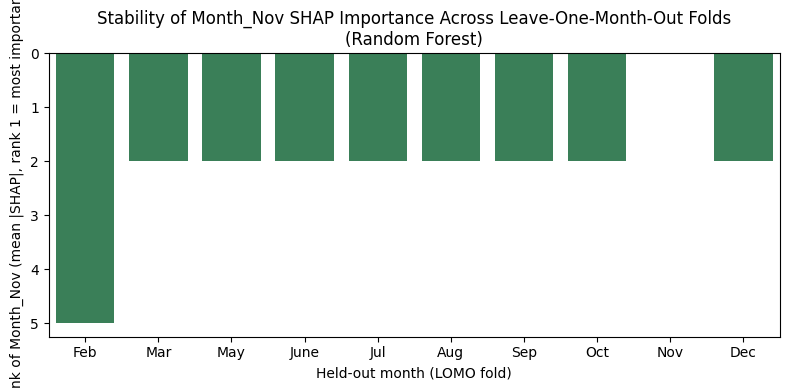

In [13]:
plot_df = nov_rank_valid.copy()
plot_df["Held_out_month"] = pd.Categorical(plot_df["Held_out_month"], categories=MONTH_ORDER, ordered=True)
plot_df = plot_df.sort_values("Held_out_month")

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="Held_out_month", y="rank", color="seagreen")
plt.gca().invert_yaxis()
plt.ylabel("Rank of Month_Nov (mean |SHAP|, rank 1 = most important)")
plt.xlabel("Held-out month (LOMO fold)")
plt.title("Stability of Month_Nov SHAP Importance Across Leave-One-Month-Out Folds\n(Random Forest)")
plt.tight_layout()
plt.savefig("rf_lomo_month_nov_rank_stability.png", dpi=200, bbox_inches="tight")
plt.show()


In [14]:
# RBO@k for LOMO SHAP rankings — top-k stability, not just full-rank correlation
def rbo(list1, list2, p=0.9):
    s, l = (list1, list2) if len(list1) <= len(list2) else (list2, list1)
    short_len, long_len = len(s), len(l)
    if short_len == 0:
        return 0.0
    x_k = 0
    rbo_sum = 0.0
    s_set, l_set = set(), set()
    for d in range(1, long_len + 1):
        if d <= short_len:
            s_set.add(s[d - 1])
        l_set.add(l[d - 1])
        x_k = len(s_set & l_set)
        rbo_sum += (p ** (d - 1)) * (x_k / d)
    rbo_ext = (1 - p) * rbo_sum
    if short_len < long_len:
        x_s = len(s_set & l_set)
        rbo_ext += (x_s * (1 - p) / short_len) * (p ** short_len) * (long_len - short_len) / long_len \
                   if short_len > 0 else 0
    return min(rbo_ext, 1.0)

def rbo_at_k(rank_df_a, rank_df_b, feature_col="feature", rank_col="rank", ks=(5, 10, None), p=0.9):
    order_a = rank_df_a.sort_values(rank_col)[feature_col].tolist()
    order_b = rank_df_b.sort_values(rank_col)[feature_col].tolist()
    rows = []
    for k in ks:
        la = order_a[:k] if k else order_a
        lb = order_b[:k] if k else order_b
        rows.append({"top_k": k if k else "all", "RBO": round(rbo(la, lb, p=p), 4), "p": p})
    return pd.DataFrame(rows)

# Compare each LOMO fold's SHAP ranking against RF's own full-data chronological ranking
rf_chrono_ranking = shap_importance_chrono  # already has columns: feature, mean_abs_shap, rank

rbo_rows = []
for fold_month in lomo_shap_all["Held_out_month"].unique():
    fold_rank = lomo_shap_all[lomo_shap_all["Held_out_month"] == fold_month]
    fold_scores = rbo_at_k(fold_rank, rf_chrono_ranking, ks=(5, 10, None))
    fold_scores["Held_out_month"] = fold_month
    rbo_rows.append(fold_scores)

rf_lomo_rbo = pd.concat(rbo_rows, ignore_index=True)
rf_lomo_rbo.to_csv("rf_lomo_rbo_at_10.csv", index=False)
rf_lomo_rbo

,top_k,RBO,p,Held_out_month
0,5,0.3380,0.9,Feb
1,10,0.5293,0.9,Feb
2,all,0.8249,0.9,Feb
3,5,0.2478,0.9,Mar
4,10,0.4489,0.9,Mar
5,all,0.7341,0.9,Mar
6,5,0.2478,0.9,May
7,10,0.4489,0.9,May
8,all,0.7459,0.9,May
9,5,0.2930,0.9,June


## 3. Bootstrap confidence intervals on the chronological holdout

In [15]:
N_BOOTSTRAPS = 1000
rng = np.random.default_rng(RANDOM_STATE)

y_test_arr = y_test_chrono.to_numpy()
y_prob_chrono = rf_chrono.predict_proba(X_test_chrono_s)[:, 1]
y_pred_chrono_arr = rf_chrono.predict(X_test_chrono_s)

boot_metrics = {"ROC_AUC": [], "PR_AUC": [], "F1": [], "MCC": []}
n = len(y_test_arr)

for _ in range(N_BOOTSTRAPS):
    idx = rng.integers(0, n, n)
    yt, yp, ypb = y_test_arr[idx], y_pred_chrono_arr[idx], y_prob_chrono[idx]
    if len(np.unique(yt)) < 2:
        continue
    boot_metrics["ROC_AUC"].append(roc_auc_score(yt, ypb))
    boot_metrics["PR_AUC"].append(average_precision_score(yt, ypb))
    boot_metrics["F1"].append(f1_score(yt, yp))
    boot_metrics["MCC"].append(matthews_corrcoef(yt, yp))

boot_summary = []
for metric, vals in boot_metrics.items():
    vals = np.array(vals)
    boot_summary.append({
        "Metric": metric,
        "Mean": round(vals.mean(), 4),
        "Std": round(vals.std(), 4),
        "CI95_low": round(np.percentile(vals, 2.5), 4),
        "CI95_high": round(np.percentile(vals, 97.5), 4),
        "N_bootstraps": len(vals),
    })

boot_summary_df = pd.DataFrame(boot_summary)
boot_summary_df.to_csv("rf_chronological_bootstrap_ci.csv", index=False)
boot_summary_df


,Metric,Mean,Std,CI95_low,CI95_high,N_bootstraps
0,ROC_AUC,0.6481,0.0084,0.6322,0.6648,1000
1,PR_AUC,0.2920,0.0116,0.2709,0.3151,1000
2,F1,0.3205,0.0121,0.2965,0.3437,1000
3,MCC,0.1171,0.0147,0.0882,0.1458,1000


## 4. Save artifacts

In [16]:
joblib.dump(rf_chrono, "shopping_model_rf_chronological.pkl")
joblib.dump(scaler_chrono, "shopping_scaler_rf_chronological.pkl")

print("Saved outputs:")
print(" - rf_gridsearch_chronological.csv            (inner 5-fold grid search results)")
print(" - rf_chronological_holdout_results.csv       (headline metrics, Oct-Dec holdout)")
print(" - rf_confusion_matrix_chronological.png")
print(" - rf_chronological_shap_importance.csv       (SHAP ranking, chronological model)")
print(" - rf_lomo_results.csv                        (per-month LOMO performance)")
print(" - rf_lomo_performance_summary.csv            (mean/SD across LOMO folds)")
print(" - rf_lomo_shap_importance_all_months.csv     (full SHAP table, every LOMO fold)")
print(" - rf_lomo_month_nov_rank_by_fold.csv         (Month_Nov SHAP rank per LOMO fold)")
print(" - rf_lomo_month_nov_rank_stability.png")
print(" - rf_chronological_bootstrap_ci.csv          (1,000-resample 95% CIs)")
print(" - shopping_model_rf_chronological.pkl, shopping_scaler_rf_chronological.pkl")


Saved outputs:
 - rf_gridsearch_chronological.csv            (inner 5-fold grid search results)
 - rf_chronological_holdout_results.csv       (headline metrics, Oct-Dec holdout)
 - rf_confusion_matrix_chronological.png
 - rf_chronological_shap_importance.csv       (SHAP ranking, chronological model)
 - rf_lomo_results.csv                        (per-month LOMO performance)
 - rf_lomo_performance_summary.csv            (mean/SD across LOMO folds)
 - rf_lomo_shap_importance_all_months.csv     (full SHAP table, every LOMO fold)
 - rf_lomo_month_nov_rank_by_fold.csv         (Month_Nov SHAP rank per LOMO fold)
 - rf_lomo_month_nov_rank_stability.png
 - rf_chronological_bootstrap_ci.csv          (1,000-resample 95% CIs)
 - shopping_model_rf_chronological.pkl, shopping_scaler_rf_chronological.pkl
